In [15]:
# Import necessary libraries and configure matplotlib parameters
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import pandas as pd 
import numpy as np
import seaborn as sns
import math
import time
import tqdm
import gc
import os
from numba import njit, prange
from joblib import Parallel, delayed
from scipy import stats
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from scipy.signal import find_peaks
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatter
from matplotlib.ticker import NullLocator
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FixedLocator
from matplotlib.ticker import LogLocator
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from brokenaxes import brokenaxes
from pathlib import Path

mpl.rcdefaults()
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 18
plt.rcParams['lines.linewidth'] = 2.8
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['axes.xmargin'] = 0.05
plt.rcParams['axes.grid']='True'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams['ytick.right'] = 'True'
plt.rcParams['xtick.minor.visible'] ='True'
plt.rcParams['ytick.minor.visible'] ='True'
plt.rcParams['xtick.major.size'] =10
plt.rcParams['xtick.minor.size'] =5
plt.rcParams['xtick.major.width'] =2
plt.rcParams['xtick.minor.width'] =1
plt.rcParams['xtick.major.pad']=8
plt.rcParams['ytick.major.size'] =10
plt.rcParams['ytick.minor.size'] =5
plt.rcParams['ytick.major.width'] =2
plt.rcParams['ytick.minor.width'] =1
plt.rcParams['ytick.major.pad']=8
plt.rcParams['figure.subplot.wspace']=0.25
plt.rcParams['figure.subplot.hspace']=0.5
plt.rcParams['grid.color'] = 'lightgray'
plt.rcParams['grid.linewidth'] = 2
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['savefig.bbox']='tight'
plt.rcParams['savefig.format']='pdf'
rc_dict = mpl.rcParams.copy()

In [17]:
# Read burst table
def Xreaddata(path, col_indices, new_col_names, startrow=0):
    if len(col_indices) != len(new_col_names):
        raise ValueError("The number of column indices must match the number of new column names.")
    df_0 = pd.read_csv(path, dtype=str)
    df = df_0.iloc[startrow:, col_indices]
    df.columns = new_col_names
    for col in df.columns:
        try:
            df[col] = df[col].astype(float)
        except ValueError:
            pass
    df = df.fillna(np.nan)
    df = df.sort_values(by='t')
    df = df.reset_index(drop=True)
    return df_0, df
    
b_fast1=Xreaddata('Data\\20201124A\\Burst_Table\\FAST#1.csv',
            [0,2,6,4],['t','s','w','f'],
            startrow=0)

b_fast2=Xreaddata('Data\\20201124A\\Burst_Table\\FAST#2.csv',
            [2,5,4,7],['t','s','w','f'],
            startrow=2) 
b_fast2[1]['s']=b_fast2[1]['s']/1000

b_ugmrt=Xreaddata('Data\\20201124A\\Burst_Table\\uGMRT.csv',
            [1,4,2,5],['t','s','w','f'],
            startrow=0)  

b_effelsberg=Xreaddata('Data\\20201124A\\Burst_Table\\Effelsberg.csv',
            [1,5,3,7],['t','s','w','f'],
            startrow=0)  

In [19]:
#Further reduce the data table
def Xselectdata2(df_s, nummin, dnum, sep):
    t_bins = np.arange(np.floor(df_s['t'].min()) - (1 - sep), np.ceil(df_s['t'].max()) + (1 - sep) + dnum, dnum)
    num, _ = np.histogram(df_s['t'], t_bins)
    date_s = np.where(num >= nummin)[0]
    date_s = date_s * dnum
    df_list = []
    for date in date_s:
        mask = np.logical_and(df_s['t'] > (date + np.floor(df_s['t'].min()) - (1 - sep)), 
                              df_s['t'] < (date + np.floor(df_s['t'].min()) - (1 - sep)) + dnum)
        df_temp = df_s.loc[mask, :].reset_index(drop=True)
        df_temp.columns = [f'{col}' for col in df_temp.columns] 
        df_list.append(df_temp)
    return df_s, df_list
    
def burstverify_anyday(bi,nummin,dnum,sep) :
    bi_ss=Xselectdata2(bi[1],nummin=nummin,dnum=dnum,sep=sep)
    b_s=[]
    for i in range(len(bi_ss[1])):
        b_s.append(bi_ss[1][i]['t']*86400)
        bi_ss[1][i]['t_s']=b_s[i]   
        waitingtime=np.diff(b_s[i])
        bi_ss[1][i]['waitingtime']=np.concatenate(([np.inf],waitingtime))
    return bi_ss

def get_cluster_representatives(df_day, threshold):
    df = df_day.sort_values('t_s').reset_index(drop=True).copy()
    t = df['t_s'].to_numpy(np.float64)
    dt_prev = np.empty_like(t)
    dt_prev[0] = np.inf
    dt_prev[1:] = np.diff(t)
    n = len(df)
    cluster_id = np.empty(n, dtype=np.int32)
    cid = 0
    for i in range(n):
        if i == 0:
            cluster_id[i] = cid
        else:
            if dt_prev[i] < threshold:
                cluster_id[i] = cid
            else:
                cid += 1
                cluster_id[i] = cid
    df['cluster_id'] = cluster_id
    reps = []
    for _, g in df.groupby('cluster_id', sort=False):
        idx = g['s'].idxmax()
        rep = g.loc[idx].copy()
        reps.append(rep)
    return pd.DataFrame(reps).reset_index(drop=True)
        

In [21]:
# Phase folding algorithm for periodicity analysis (numba)
@njit(parallel=True, fastmath=True)
def phase_fold_and_calc_chi2_opt(t, p_arr, bins_num):
    N = t.shape[0]
    M = p_arr.shape[0]
    chi_arr = np.empty(M, dtype=np.float32)
    q = 1.0 + (bins_num + 1) / (6.0 * N)      # Williams correction
    E = N / bins_num                          
    inv_norm = 1.0 / (E * (bins_num - 1) * q) 
    for i in prange(M):
        p = p_arr[i]
        inv_p = 1.0 / p
        O = np.zeros(bins_num, dtype=np.int32)
        for n in range(N):
            phase = (t[n] * inv_p) % 1.0   # in [0, 1)
            idx = int(phase * bins_num)
            if idx == bins_num:
                idx = bins_num - 1
            O[idx] += 1
        s2 = 0.0
        for b in range(bins_num):
            cnt = float(O[b])
            s2 += cnt * cnt
        chi_arr[i] = (s2 - N * E) * inv_norm
    return chi_arr


def segmented_search_chi2(b_ss, day, ps, pe, step, bins_num, threshold):
    def _get_rep_times(df_day, threshold):
        b_rep = get_cluster_representatives(df_day, threshold)
        return np.asarray(b_rep["t_s"], dtype=np.float64)
    if step <= 0:
        raise ValueError("Step size must be positive.")
    if pe < ps:
        raise ValueError("End period must be greater than start period.")
    df_day = b_ss[1][day]
    num_points = int(np.round((pe - ps) / step)) + 1
    p_arr = np.linspace(ps, pe, num_points, dtype=np.float64)
    
    split = float(threshold) * 2.0
    t_all = np.asarray(df_day["t_s"], dtype=np.float64)
    mask_long = p_arr >= split
    has_long = np.any(mask_long)
    has_short = np.any(~mask_long)
    if not has_long:
        chi2_arr = phase_fold_and_calc_chi2_opt(t_all, p_arr, bins_num)
    
    elif not has_short:
        t_rep = _get_rep_times(df_day, threshold)
        chi2_arr = phase_fold_and_calc_chi2_opt(t_rep, p_arr, bins_num)
    
    else:
        p_short = p_arr[~mask_long]
        p_long  = p_arr[mask_long]
        
        chi2_short = phase_fold_and_calc_chi2_opt(t_all, p_short, bins_num)
        
        t_rep = _get_rep_times(df_day, threshold)
        chi2_long = phase_fold_and_calc_chi2_opt(t_rep, p_long, bins_num)
        
        chi2_arr = np.concatenate([chi2_short, chi2_long])
        
        del chi2_short, chi2_long
        gc.collect()
    best_idx = np.argmax(chi2_arr)
    best_p = p_arr[best_idx]
    result = {
        "chi2_array": chi2_arr.astype(np.float32),
        "best_p": best_p,  
        "max_chi2": chi2_arr[best_idx],
        "MJD": np.floor(np.min(df_day["t"])) if len(df_day) > 0 else 0,
        "N_burst": int(len(df_day)),
    }
    return result

In [ ]:
# Plot periodograms (Supplementary Figure 1
b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)
pf='Periodograms\\'
for i in tqdm.tqdm(range(45)):   
    ps=0.1
    pe=100
    step=1e-5
    threshold = 0.5
    bins_num = 20
    filename=f'chi2_fast1_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    np.savez_compressed(pf+filename, **segmented_search_chi2(b_ss, i, ps, pe, step, bins_num, threshold))
    gc.collect()

for i in tqdm.tqdm(range(45)):
    filename=f'chi2_fast1_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    sig=stats.chi2.isf((1 - stats.norm.cdf(3))/((pe-ps)/step), bins_num-1)/(bins_num-1)
    r = np.load(pf+filename)
    mpl.use('Agg')
    fig, ax=plt.subplots()
    ax.plot(np.linspace(ps,pe,int(np.round((pe-ps)/step))+1), r['chi2_array'], alpha=1, lw=2, color='royalblue')
    ax.set_xscale('log')
    ax.axhline(sig, color='red', linestyle='dotted')
    ax.text(0.05, 0.95, 'FAST #1 MJD %i' % r['MJD'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.text(0.05, 0.86, '%i bursts' % r['N_burst'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.set_xlim(0.1, 100)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.set_ylim(-0.5,8.5)
    ax.set_xlabel('Period (s)',fontsize=24)
    ax.set_ylabel('$\\chi ^{2}$',fontsize=24)
    filename=f'chi2_fast1_day{i:02d}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    output_file = Path(pf+filename)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file.with_suffix('.svg'))
    plt.close(fig)   
    plt.close('all') 
    del r, fig, ax
    gc.collect()
    

b_ss=burstverify_anyday(b_fast2, nummin=1,dnum=1,sep=0)
for i in tqdm.tqdm(range(4)):   
    ps=0.1
    pe=100
    step=1e-5
    threshold = 0.5
    bins_num = 20
    filename=f'chi2_fast2_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    np.savez_compressed(pf+filename, **segmented_search_chi2(b_ss, i, ps, pe, step, bins_num, threshold))
    gc.collect()

for i in tqdm.tqdm(range(4)):
    filename=f'chi2_fast2_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    sig=stats.chi2.isf((1 - stats.norm.cdf(3))/((pe-ps)/step), bins_num-1)/(bins_num-1)
    r = np.load(pf+filename)
    mpl.use('Agg')
    fig, ax=plt.subplots()
    ax.plot(np.linspace(ps,pe,int(np.round((pe-ps)/step))+1), r['chi2_array'], alpha=1, lw=2, color='royalblue')
    ax.set_xscale('log')
    ax.axhline(sig, color='red', linestyle='dotted')
    ax.text(0.05, 0.95, 'FAST #2 MJD %i' % r['MJD'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.text(0.05, 0.86, '%i bursts' % r['N_burst'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.set_xlim(0.1, 100)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.set_ylim(-0.5,8.5)
    ax.set_xlabel('Period (s)',fontsize=24)
    ax.set_ylabel('$\\chi ^{2}$',fontsize=24)
    output_file = Path(pf+filename)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file.with_suffix('.svg'))
    plt.close(fig)  
    plt.close('all')
    del r, fig, ax
    gc.collect()


b_ss=burstverify_anyday(b_ugmrt, nummin=1,dnum=1,sep=0)
for i in tqdm.tqdm(range(1)):   
    ps=0.1
    pe=100
    step=1e-5
    threshold = 0.5
    bins_num = 20
    filename=f'chi2_ugmrt_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    np.savez_compressed(pf+filename, **segmented_search_chi2(b_ss, i, ps, pe, step, bins_num, threshold))
    gc.collect()

for i in tqdm.tqdm(range(1)):
    filename=f'chi2_ugmrt_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    sig=stats.chi2.isf((1 - stats.norm.cdf(3))/((pe-ps)/step), bins_num-1)/(bins_num-1)
    r = np.load(pf+filename)
    mpl.use('Agg')
    fig, ax=plt.subplots()
    ax.plot(np.linspace(ps,pe,int(np.round((pe-ps)/step))+1), r['chi2_array'], alpha=1, lw=2, color='royalblue')
    ax.set_xscale('log')
    ax.axhline(sig, color='red', linestyle='dotted')
    ax.text(0.05, 0.95, 'uGMRT MJD %i' % r['MJD'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.text(0.05, 0.86, '%i bursts' % r['N_burst'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.set_xlim(0.1, 100)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.set_ylim(-0.5,8.5)
    ax.set_xlabel('Period (s)',fontsize=24)
    ax.set_ylabel('$\\chi ^{2}$',fontsize=24)
    output_file = Path(pf+filename)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file.with_suffix('.svg'))
    plt.close(fig)   
    plt.close('all') 
    del r, fig, ax
    gc.collect()


b_ss=burstverify_anyday(b_effelsberg, nummin=1,dnum=1,sep=0)
for i in tqdm.tqdm(range(1)):   
    ps=0.1
    pe=100
    step=1e-5
    threshold = 0.5
    bins_num = 20
    filename=f'chi2_effelsberg_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    np.savez_compressed(pf+filename, **segmented_search_chi2(b_ss, i, ps, pe, step, bins_num, threshold))
    gc.collect()

for i in tqdm.tqdm(range(1)):
    filename=f'chi2_effelsberg_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    sig=stats.chi2.isf((1 - stats.norm.cdf(3))/((pe-ps)/step), bins_num-1)/(bins_num-1)
    r = np.load(pf+filename)
    mpl.use('Agg')
    fig, ax=plt.subplots()
    ax.plot(np.linspace(ps,pe,int(np.round((pe-ps)/step))+1), r['chi2_array'], alpha=1, lw=2, color='royalblue')
    ax.set_xscale('log')
    ax.axhline(sig, color='red', linestyle='dotted')
    ax.text(0.05, 0.95, 'Effelsberg MJD %i' % r['MJD'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.text(0.05, 0.86, '%i bursts' % r['N_burst'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.set_xlim(0.1, 100)
    ax.yaxis.set_major_locator(MultipleLocator(2))
    ax.set_ylim(-0.5,8.5)
    ax.set_xlabel('Period (s)',fontsize=24)
    ax.set_ylabel('$\\chi ^{2}$',fontsize=24)
    output_file = Path(pf+filename)
    output_file.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_file.with_suffix('.svg'))
    plt.close(fig)   
    plt.close('all') 
    del r, fig, ax
    gc.collect()

print('Please find periodograms for all MJDs in "Periodograms" folder.')

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.21s/it]

Please find periodograms for all MJDs in "Periodograms" folder.


Observed:
  P_59310 = 1.706024 s
  P_59347 = 1.707968 s
  dP_obs  = 1.944000e-03 s
  chi2_59310 = 6.05
  chi2_59347 = 5.28
  X_obs_low  = 5.28
  X_obs_high = 6.05


Scan for the global minimum/maximum values: 100%|██████████████████████████████████████| 51/51 [00:03<00:00, 14.22it/s]


Global range: [0.04444444552063942, 6.0480146408081055]


Accumulate histogram: 100%|████████████████████████████████████████████████████████████| 51/51 [00:12<00:00,  4.16it/s]


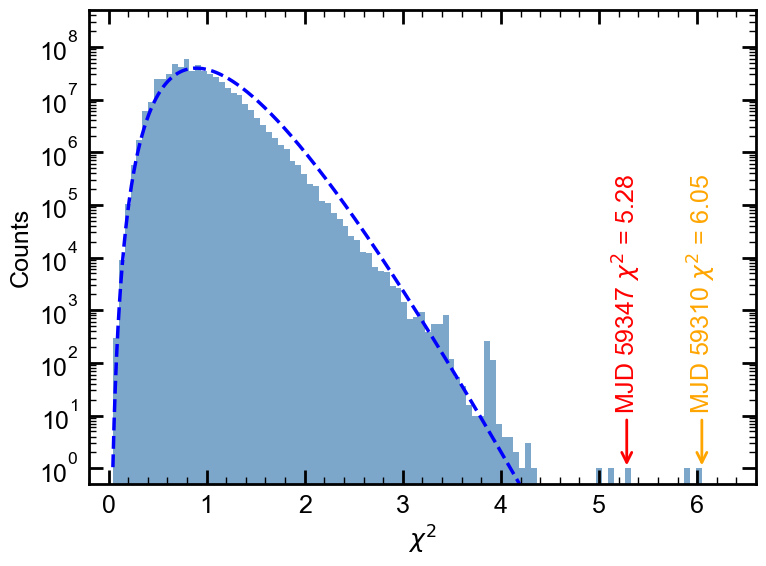

In [17]:
# Plot Supplementary Figure 2
# Quantitative analysis of periodograms
%matplotlib inline
pf = r'Periodograms'
ps = 0.1
pe = 100
step = 1e-5
threshold = 0.5
bins_num = 20
hist_bins = 100   

# Observed candidate period
P_59310 = 1.706024
P_59347 = 1.707968

dP_obs = abs(P_59347 - P_59310)

# Observed periodogram powers under the adopted configuration
chi2_59310 = 6.0480146408081055
chi2_59347 = 5.282492160797119

X_obs_low = min(chi2_59310, chi2_59347)
X_obs_high = max(chi2_59310, chi2_59347)

print('Observed:')
print(f'  P_59310 = {P_59310:.6f} s')
print(f'  P_59347 = {P_59347:.6f} s')
print(f'  dP_obs  = {dP_obs:.6e} s')
print(f'  chi2_59310 = {chi2_59310:.2f}')
print(f'  chi2_59347 = {chi2_59347:.2f}')
print(f'  X_obs_low  = {X_obs_low:.2f}')
print(f'  X_obs_high = {X_obs_high:.2f}')

filenames = []

for i in range(0,45):
    filenames.append(
        f'chi2_fast1_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    )

for i in range(0, 4):
    filenames.append(
        f'chi2_fast2_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    )

for i in range(0, 1):
    filenames.append(
        f'chi2_ugmrt_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    )

for i in range(0, 1):
    filenames.append(
        f'chi2_effelsberg_day{i}_b{bins_num}_ps{ps}_pe{pe}_step{step}_th{threshold}.npz'
    )


# =========================
#  Scan for the global minimum/maximum values
# =========================
global_min = np.inf
global_max = -np.inf

for filename in tqdm.tqdm(filenames, desc='Scan for the global minimum/maximum values'):
    fullpath = os.path.join(pf, filename)
    with np.load(fullpath) as r:
        arr = r['chi2_array']

        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            continue

        arr_min = arr.min()
        arr_max = arr.max()

        if arr_min < global_min:
            global_min = arr_min
        if arr_max > global_max:
            global_max = arr_max

print(f'Global range: [{global_min}, {global_max}]')

# =========================
#  Accumulate histogram
# =========================
bin_edges = np.linspace(global_min, global_max, hist_bins + 1)
hist_counts = np.zeros(hist_bins, dtype=np.int64)

for filename in tqdm.tqdm(filenames, desc='Accumulate histogram'):
    fullpath = os.path.join(pf, filename)
    with np.load(fullpath) as r:
        arr = r['chi2_array']

        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            continue

        counts, _ = np.histogram(arr, bins=bin_edges)
        hist_counts += counts

# =========================
#  Empirical chi-square histogram vs Theoretical chi-square distribution
# =========================
nu = 19  # degrees of freedom = 19

N_total = hist_counts.sum()
bin_width = bin_edges[1] - bin_edges[0]

# x grid for theoretical curve
x_theory = np.linspace(max(1e-6, bin_edges[0]), bin_edges[-1], 2000)

# Reduced chi-square distribution:
# X = chi2_nu / nu
# pdf_X(x) = nu * pdf_chi2(nu*x)
pdf_redchi = nu * stats.chi2.pdf(nu * x_theory, df=nu)

# Convert PDF to expected counts per bin
counts_redchi = pdf_redchi * N_total * bin_width

plt.figure(figsize=(8, 6))

plt.stairs(
    hist_counts,
    bin_edges,
    fill=True,
    alpha=0.7,
    color='steelblue',
    label='$\\chi^2$ values'
)

plt.plot(
    x_theory,
    counts_redchi,
    color='blue',
    lw=2.5,
    ls='--',
    label='Theoretical $\\chi^2$ curve'
)

plt.annotate(
    f'MJD 59310 $\\chi^2$ = {chi2_59310:.2f}',
    xy=(chi2_59310, 1),
    xytext=(chi2_59310, 2e3),
    rotation=90,
    ha='center',
    va='center',
    color='orange',
    arrowprops=dict(arrowstyle='->', color='orange', lw=2)
)

plt.annotate(
    f'MJD 59347 $\\chi^2$ = {chi2_59347:.2f}',
    xy=(chi2_59347, 1),
    xytext=(chi2_59347, 2e3),
    rotation=90,
    ha='center',
    va='center',
    color='r',
    arrowprops=dict(arrowstyle='->', color='r', lw=2)
)
plt.grid()
plt.yscale('log')
plt.ylim(0.5, 5e8)
plt.xlim(-0.2, 6.6)
plt.xlabel('$\\chi^2$')
plt.ylabel('Counts')
ax=plt.gca()
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)
minor_ticks = ax.yaxis.get_minorticklocs()
minor_ticks = minor_ticks[minor_ticks >= 1]
ax.yaxis.set_minor_locator(FixedLocator(minor_ticks))
# plt.legend(fontsize=16)
plt.tight_layout()
plt.show()


Grid settings:
  X_grid range  = 2.500 -- 6.500, nX = 102
  dP_grid range = 1.000e-04 -- 1.000e+00 s, nD = 102
  X_base = 2.500
  Observed X_low = 5.2825, nearest grid = 5.2825
  Observed dP    = 1.944000e-03 s, nearest grid = 1.944000e-03 s

Peak-extraction settings:
  peak_distance_bins   = 10
  peak_distance_period = 1.000e-04 s
  peak_prominence      = None

Extracting local peaks from all periodograms...


Extract local peaks: 100%|█████████████████████████████████████████████████████████████| 51/51 [00:07<00:00,  6.97it/s]



Base peak catalog:
  X_base = 2.500
  Total base peaks = 33930
  M_pair = 558379877

Computing empirical peak-level counts...


Empirical counts: 100%|██████████████████████████████████████████████████████████████| 102/102 [00:27<00:00,  3.70it/s]



Observed-point empirical fractions:
  X_obs grid  = 5.2825
  dP_obs grid = 1.944000e-03 s

Peak-level:
  C_obs = 1
  M_pair = 558379877
  f_pair_uncond = 1.790895e-09


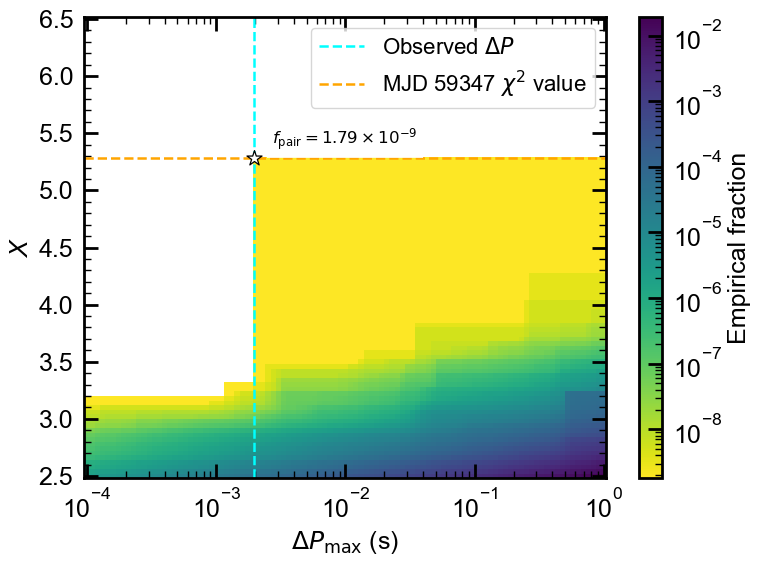

In [19]:
# Plot Supplementary Figure 3
# Quantitative analysis of periodograms


# ============================================================
# Define threshold and period-separation grids
# ============================================================

# Detection-threshold grid
X_grid = np.linspace(2.5, 6.5, 101)
X_grid = np.unique(np.sort(np.append(X_grid, X_obs_low)))

# Maximum allowed period-difference grid
dP_grid = np.logspace(-4, 0, 101)
dP_grid = np.unique(np.sort(np.append(dP_grid, dP_obs)))

# Convert period difference into grid-index difference
W_grid = np.floor(dP_grid / step).astype(np.int64)
W_grid = np.maximum(W_grid, 0)

# Base threshold for the peak catalog
# Local peaks are extracted only above this threshold.
X_base = np.min(X_grid)

# Observed-point grid indices
idx_X_obs = np.argmin(np.abs(X_grid - X_obs_low))
idx_dP_obs = np.argmin(np.abs(dP_grid - dP_obs))

print('\nGrid settings:')
print(f'  X_grid range  = {X_grid[0]:.3f} -- {X_grid[-1]:.3f}, nX = {len(X_grid)}')
print(f'  dP_grid range = {dP_grid[0]:.3e} -- {dP_grid[-1]:.3e} s, nD = {len(dP_grid)}')
print(f'  X_base = {X_base:.3f}')
print(f'  Observed X_low = {X_obs_low:.4f}, nearest grid = {X_grid[idx_X_obs]:.4f}')
print(f'  Observed dP    = {dP_obs:.6e} s, nearest grid = {dP_grid[idx_dP_obs]:.6e} s')


# ============================================================
#  Local-peak extraction parameters
# ============================================================

# Minimum distance between neighbouring local peaks in period-grid bins.
# This avoids counting many tiny maxima around the same broad peak.
peak_distance_bins = max(1, int(1e-4 / step))  # default: 1e-4 s

# Optional prominence cut. Use None if no prominence cut is desired.
peak_prominence = None

print('\nPeak-extraction settings:')
print(f'  peak_distance_bins   = {peak_distance_bins}')
print(f'  peak_distance_period = {peak_distance_bins * step:.3e} s')
print(f'  peak_prominence      = {peak_prominence}')


# ============================================================
#  Helper functions
# ============================================================

def min_abs_diff_sorted(A, B):
    """
    Minimum absolute difference between two sorted integer arrays.
    Return np.inf if either array is empty.
    """
    if len(A) == 0 or len(B) == 0:
        return np.inf

    i = 0
    j = 0
    best = np.inf

    while i < len(A) and j < len(B):
        diff = abs(int(A[i]) - int(B[j]))

        if diff < best:
            best = diff

        if best == 0:
            return 0

        if A[i] < B[j]:
            i += 1
        else:
            j += 1

    return best


def count_close_peak_pairs_sorted(A, B, W):
    """
    Count cross pairs (a, b), with a in A and b in B,
    satisfying |a - b| <= W.

    A and B must be sorted integer arrays.
    """
    if len(A) == 0 or len(B) == 0:
        return 0

    # Iterate over the shorter array for speed
    if len(A) > len(B):
        A, B = B, A

    left = np.searchsorted(B, A - W, side='left')
    right = np.searchsorted(B, A + W, side='right')

    return int(np.sum(right - left))



# # ============================================================
# #  Determine period-grid size
# # ============================================================

# first_fullpath = os.path.join(pf, filenames[0])

# with np.load(first_fullpath) as r:
#     nP = len(r['chi2_array'])

# print('\nPeriod-grid information:')
# print(f'  nP = {nP}')
# print(f'  Period range implied by grid: {ps:.6f} -- {ps + (nP - 1) * step:.6f} s')


# ============================================================
# 6. Extract local peaks from all periodograms
# ============================================================

print('\nExtracting local peaks from all periodograms...')

peak_idx_lists = []
peak_chi_lists = []
n_peaks_each = []

for filename in tqdm.tqdm(filenames, desc='Extract local peaks'):

    fullpath = os.path.join(pf, filename)

    with np.load(fullpath) as r:
        arr = r['chi2_array'].astype(np.float32)

    # Replace non-finite values so that they cannot be selected as peaks
    arr_work = arr.copy()
    arr_work[~np.isfinite(arr_work)] = -np.inf

    if peak_prominence is None:
        peaks, props = find_peaks(
            arr_work,
            height=X_base,
            distance=peak_distance_bins
        )
    else:
        peaks, props = find_peaks(
            arr_work,
            height=X_base,
            distance=peak_distance_bins,
            prominence=peak_prominence
        )

    peaks = peaks.astype(np.int64)
    chis = arr_work[peaks].astype(np.float32)

    # Sort by period-grid index
    order = np.argsort(peaks)
    peaks = peaks[order]
    chis = chis[order]

    peak_idx_lists.append(peaks)
    peak_chi_lists.append(chis)
    n_peaks_each.append(len(peaks))

n_peaks_each = np.array(n_peaks_each, dtype=np.int64)

# print('\nSummary of extracted local peaks:')
# print(f'  Number of periodograms              = {len(filenames)}')
# print(f'  Total local peaks above X_base       = {np.sum(n_peaks_each)}')


# ============================================================
#  Compute base denominators
# ============================================================

nE = len(peak_idx_lists)

# Number of base peaks in each epoch
n_base_each = np.array([len(x) for x in peak_idx_lists], dtype=np.int64)

total_base_peaks = int(np.sum(n_base_each))

# Cross-epoch peak-pair denominator:
# M_pair = sum_{a<b} n_a n_b
same_epoch_square_sum = int(np.sum(n_base_each * n_base_each))
M_pair = (total_base_peaks * total_base_peaks - same_epoch_square_sum) // 2


print('\nBase peak catalog:')
print(f'  X_base = {X_base:.3f}')
print(f'  Total base peaks = {total_base_peaks}')
print(f'  M_pair = {M_pair}')


# ============================================================
# 8. Compute C_pair over the grid
# ============================================================

print('\nComputing empirical peak-level counts...')

nX = len(X_grid)
nD = len(dP_grid)

# Peak-level count:
# C_pair[X, dP] = number of cross-epoch peak pairs satisfying
# chi1 >= X, chi2 >= X, and |P1 - P2| <= dP.
C_pair = np.zeros((nX, nD), dtype=np.int64)


for it, X in enumerate(tqdm.tqdm(X_grid, desc='Empirical counts')):

    # Select peaks above the current threshold for each epoch
    idx_X_lists = []

    for idx_arr, chi_arr in zip(peak_idx_lists, peak_chi_lists):
        idx_now = idx_arr[chi_arr >= X].astype(np.int64)
        idx_now.sort()
        idx_X_lists.append(idx_now)

    # Active epochs at this threshold
    active_epochs = [i for i in range(nE) if len(idx_X_lists[i]) > 0]

    if len(active_epochs) < 2:
        continue

    # Loop over all active epoch pairs
    for aa in range(len(active_epochs)):
        i = active_epochs[aa]
        A = idx_X_lists[i]

        for bb in range(aa + 1, len(active_epochs)):
            j = active_epochs[bb]
            B = idx_X_lists[j]

            if len(A) == 0 or len(B) == 0:
                continue

            # Peak-level count:
            # number of close peak pairs for each dP threshold.
            for idp, W in enumerate(W_grid):
                C_pair[it, idp] += count_close_peak_pairs_sorted(A, B, W)


# ============================================================
# 9. Compute unconditional empirical fractions
# ============================================================

f_pair_uncond_grid = C_pair / M_pair


# ============================================================
# 10. Print observed-point values
# ============================================================

C_obs = int(C_pair[idx_X_obs, idx_dP_obs])

f_pair_uncond_obs = C_obs / M_pair

print('\nObserved-point empirical fractions:')
print(f'  X_obs grid  = {X_grid[idx_X_obs]:.4f}')
print(f'  dP_obs grid = {dP_grid[idx_dP_obs]:.6e} s')

print('\nPeak-level:')
print(f'  C_obs = {C_obs}')
print(f'  M_pair = {M_pair}')
print(f'  f_pair_uncond = {f_pair_uncond_obs:.6e}')


# ============================================================
# 11. Plot heatmaps
# ============================================================

# annot_peak = (
#     rf'$f_{{\rm pair}}={f_pair_uncond_obs:.2e}$'
# )

mantissa, exponent = f'{f_pair_uncond_obs:.2e}'.split('e')
annot_peak = rf'$f_{{\rm pair}}={mantissa}\times 10^{{{int(exponent)}}}$'


plt.figure(figsize=(8,6))


f_pair_uncond_grid = np.array(f_pair_uncond_grid, dtype=float)
f_pair_uncond_grid[f_pair_uncond_grid <= 0] = np.nan

mesh = plt.pcolormesh(
    dP_grid,
    X_grid,
    f_pair_uncond_grid,
    shading='auto',
    cmap='viridis_r',
    # norm=None
    norm=LogNorm(vmin=np.nanmin(f_pair_uncond_grid), vmax=np.nanmax(f_pair_uncond_grid))
)

plt.xscale('log')
cbar = plt.colorbar(mesh)
cbar.set_label('Empirical fraction')
plt.axvline(dP_obs, color='cyan', ls='--', lw=1.8, label='Observed $\\Delta P$')
plt.axhline(X_obs_low, color='orange', ls='--', lw=1.8, label='MJD 59347 $\\chi^2$ value')

plt.scatter(
    [dP_obs],
    [X_obs_low],
    marker='*',
    s=130,
    color='white',
    edgecolor='black',
    linewidth=0.9,
    zorder=5,
)
plt.legend(loc='upper right', fontsize=16)


plt.text(
    dP_obs * 1.4,
    X_obs_low + 0.12,
    annot_peak,
    fontsize=12,
    color='black',
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none')
)

plt.xlabel('$\\Delta P_{\\max}$ (s)')
plt.ylabel('$X$')
plt.grid()
plt.tight_layout()
plt.show()

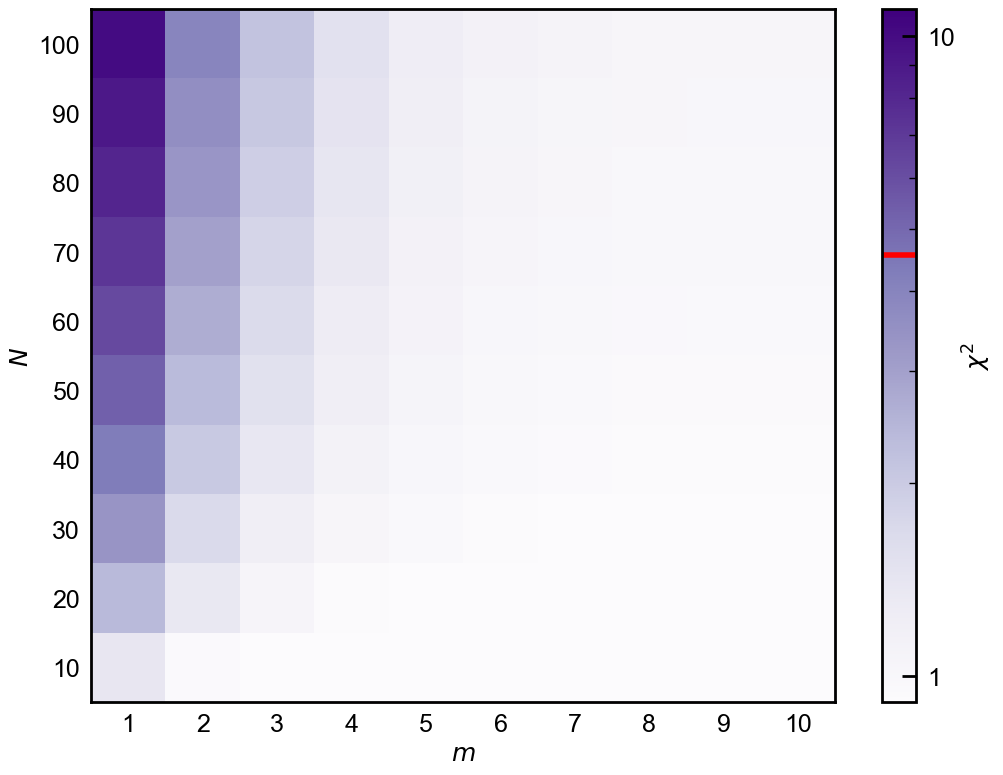

In [13]:
# Plot Supplementary Figure 4
# These simulated samples are consistent with those in the paper. 
# For details on how they were generated, please refer to 'Multiple_emission_sites.py' in the same directory.
chi2_matrix=np.load('Data\\chi2_matrix.npy')

n_values = [100,90,80,70,60,50,40,30,20,10]
m_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
fig, ax = plt.subplots(figsize=(12, 9))
cax=ax.imshow(chi2_matrix, cmap='Purples', aspect='auto', norm=LogNorm(0.91,11))
cbar=fig.colorbar(cax,format=LogFormatter(10, labelOnlyBase=False))
plt.xlabel('$m$')
plt.ylabel('$N$')
plt.yticks([0,1,2,3,4,5,6,7,8,9],n_values)
plt.xticks([0,1,2,3,4,5,6,7,8,9],m_values)
plt.minorticks_off()
plt.tick_params(top=False,bottom=False,left=False,right=False)
cbar.set_label('$\\chi^2$')
thpf_1= stats.chi2.isf((1 - stats.norm.cdf(3))/((100-0.1)/1e-5), 20-1)/(20-1)
cbar.ax.hlines(thpf_1, *cbar.ax.get_xlim(), color='red', linewidth=4)
plt.grid(False)

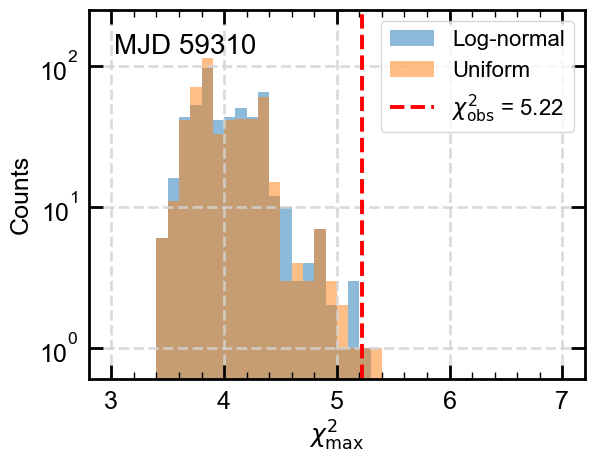

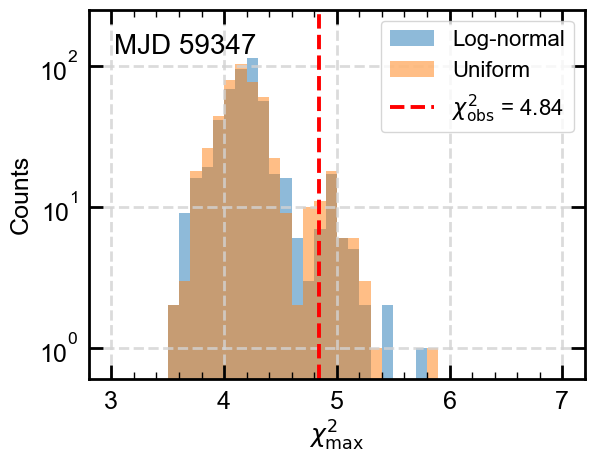

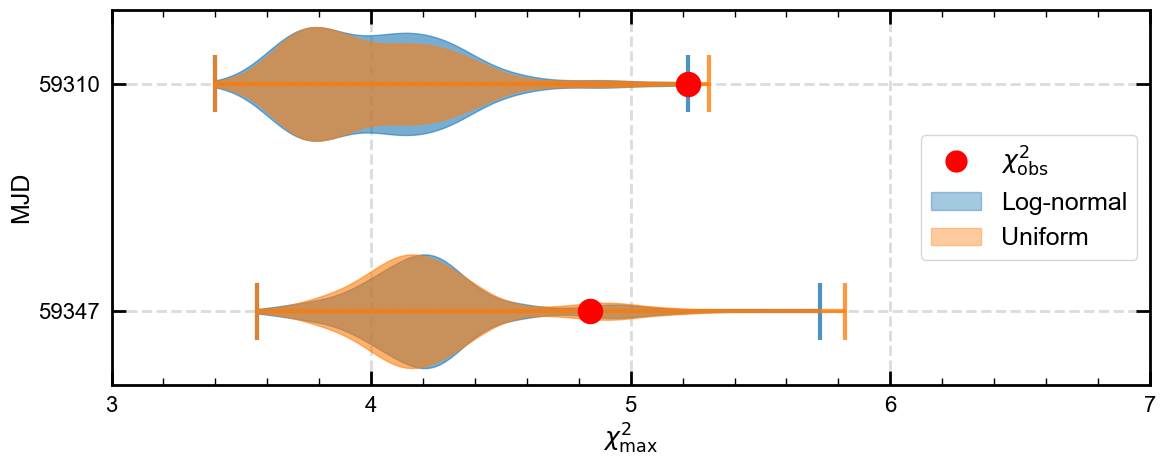

In [21]:
# Plot Supplementary Figure 5
# These simulated samples are consistent with those in the paper. 
# For details on how they were generated, please refer to 'Comparison_analysis.py'.
pf=r'Comparison_results\\'
filename_load_uniform=f'chi2_nulluniform_seed1_b30_num500_ps0.1_pe10_step1e-07_th0.4_first.npz'
mc_results_chi2_uniform = np.load(pf+filename_load_uniform)
chi2_days_uniform=mc_results_chi2_uniform['chi2_days_uniform']
chi2_period_days_uniform=mc_results_chi2_uniform['chi2_period_days_uniform']
chi2_days_obs=mc_results_chi2_uniform['chi2_days_obs']
chi2_period_days_obs=mc_results_chi2_uniform['chi2_period_days_obs']
meanT_days_uniform=mc_results_chi2_uniform['meanT_days']

filename_load_lognormal=f'chi2_nulllognormal_seed1_b30_num500_ps0.1_pe10_step1e-07_th0.4_first.npz'
mc_results_chi2_lognormal = np.load(pf+filename_load_lognormal)
chi2_days_lognormal=mc_results_chi2_lognormal['chi2_days_lognormal']
chi2_period_days_lognormal=mc_results_chi2_lognormal['chi2_period_days_lognormal']
chi2_days_obs1=mc_results_chi2_lognormal['chi2_days_obs']
chi2_period_days_obs1=mc_results_chi2_lognormal['chi2_period_days_obs']
meanT_days_lognormal=mc_results_chi2_lognormal['meanT_days']

# --- MJD 59310 ---
fig, ax=plt.subplots(1,1)
plt.hist(chi2_days_lognormal[0,:],bins=np.linspace(3,7,41),label='Log-normal',rwidth=1,alpha=0.5)
plt.hist(chi2_days_uniform[0,:],bins=np.linspace(3,7,41),label='Uniform',rwidth=1,alpha=0.5)
plt.axvline(chi2_days_obs[0],ls='--',color='r',label='$\\chi^2_{\\mathrm{obs}}$ = %.2f'%chi2_days_obs[0])
plt.yscale('log')
plt.ylim(0.6,0.25e3)
plt.text(0.05,0.88,'MJD 59310',transform=ax.transAxes,fontsize=20)
plt.ylabel('Counts')
plt.xlabel('$\\chi^2_{\\mathrm{max}}$')
plt.legend(loc='upper right',fontsize=16)
ax.yaxis.set_minor_locator(mticker.NullLocator())

# --- MJD 59347 ---
fig, ax=plt.subplots(1,1)
plt.hist(chi2_days_lognormal[1,:],bins=np.linspace(3,7,41),label='Log-normal',rwidth=1,alpha=0.5)
plt.hist(chi2_days_uniform[1,:],bins=np.linspace(3,7,41),label='Uniform',rwidth=1,alpha=0.5)
plt.axvline(chi2_days_obs[1],ls='--',color='r',label='$\\chi^2_{\\mathrm{obs}}$ = %.2f'%chi2_days_obs[1])
plt.yscale('log')
plt.ylim(0.6,0.25e3)
plt.text(0.05,0.88,'MJD 59347',transform=ax.transAxes,fontsize=20)
plt.ylabel('Counts')
plt.xlabel('$\\chi^2_{\\mathrm{max}}$')
plt.legend(loc='upper right',fontsize=16)
ax.yaxis.set_minor_locator(mticker.NullLocator())


dates_mjd=[]
fn_chi2days_lognormal=[chi2_days_lognormal[0,:],chi2_days_lognormal[1,:]]
fn_chi2days_possion=[chi2_days_uniform[0,:],chi2_days_uniform[1,:]]
chi2days_obs=chi2_days_obs

fig, ax = plt.subplots(figsize=(12,5)) 

violin_width = 0.5 
        

def customize_violin(vp, color):

    for pc in vp['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.6)
        pc.set_zorder(2)

    for partname in ('cbars', 'cmins', 'cmaxes'):
        if partname in vp:
            vp[partname].set_edgecolor(color) 
            vp[partname].set_linewidth(3)
            vp[partname].set_alpha(0.8)
            
# --- MJD 59310 ---
vp1_1 = ax.violinplot(fn_chi2days_lognormal[0], positions=[1], vert=False, 
                    showmeans=0, showmedians=0, showextrema=True, widths=violin_width)
customize_violin(vp1_1, 'tab:blue')
vp2_1 = ax.violinplot(fn_chi2days_possion[0], positions=[1], vert=False, 
                    showmeans=0, showmedians=0, showextrema=True, widths=violin_width)
customize_violin(vp2_1, 'tab:orange')
# --- MJD 59347  ---
vp1_2 = ax.violinplot(fn_chi2days_lognormal[1], positions=[2], vert=False, 
                    showmeans=False, showmedians=False, showextrema=True, widths=violin_width)
customize_violin(vp1_2, 'tab:blue')
vp2_2 = ax.violinplot(fn_chi2days_possion[1], positions=[2], vert=False, 
                    showmeans=False, showmedians=False, showextrema=True, widths=violin_width)
customize_violin(vp2_2, 'tab:orange')

ax.scatter(chi2days_obs[0],1,color='r', 
            s=300, zorder=3)
ax.scatter(chi2days_obs[1],2,color='r', 
            s=300, zorder=3)

ax.set_yticks([1,2],[59310,59347]) 
plt.gca().invert_yaxis()
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_ylabel("MJD") 
ax.set_xlabel("$\\chi^2_{\\mathrm{max}}$") 
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.set_xlim(3,7)

obs_handle = Line2D([0], [0], marker='o', color='r', label='$\\chi^2_{\\mathrm{obs}}$', 
                       linestyle='None', markersize=15)
lognormal_handle = mpatches.Patch(color='tab:blue', alpha=0.4, label='Log-normal')
possion_handle = mpatches.Patch(color='tab:orange', alpha=0.4, label='Uniform')

ax.legend(loc='center right',handles=[obs_handle,lognormal_handle, possion_handle])
plt.tight_layout() 


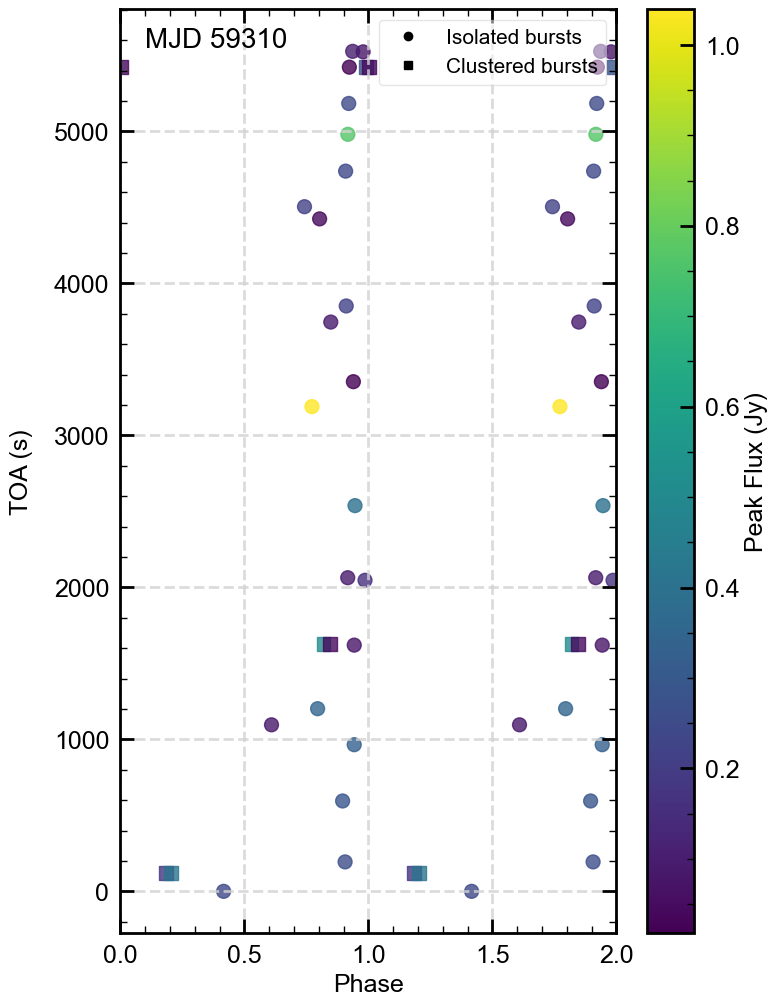

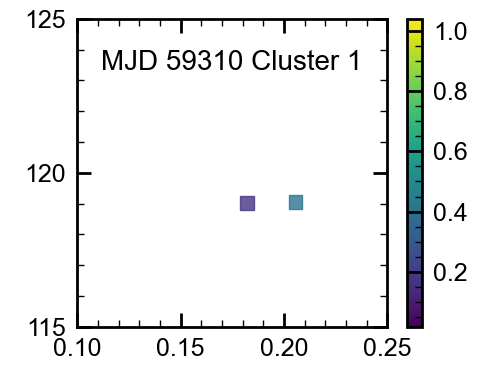

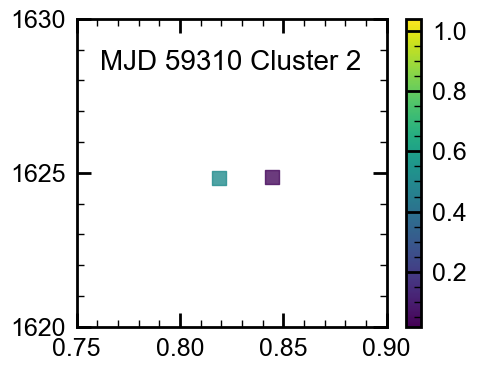

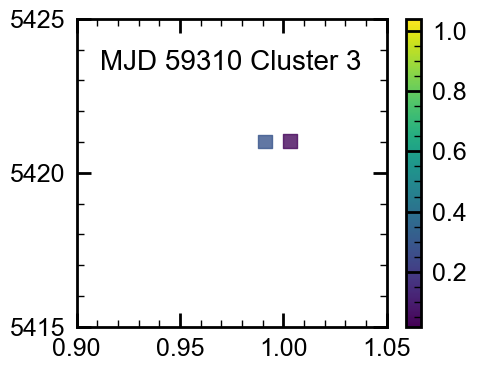

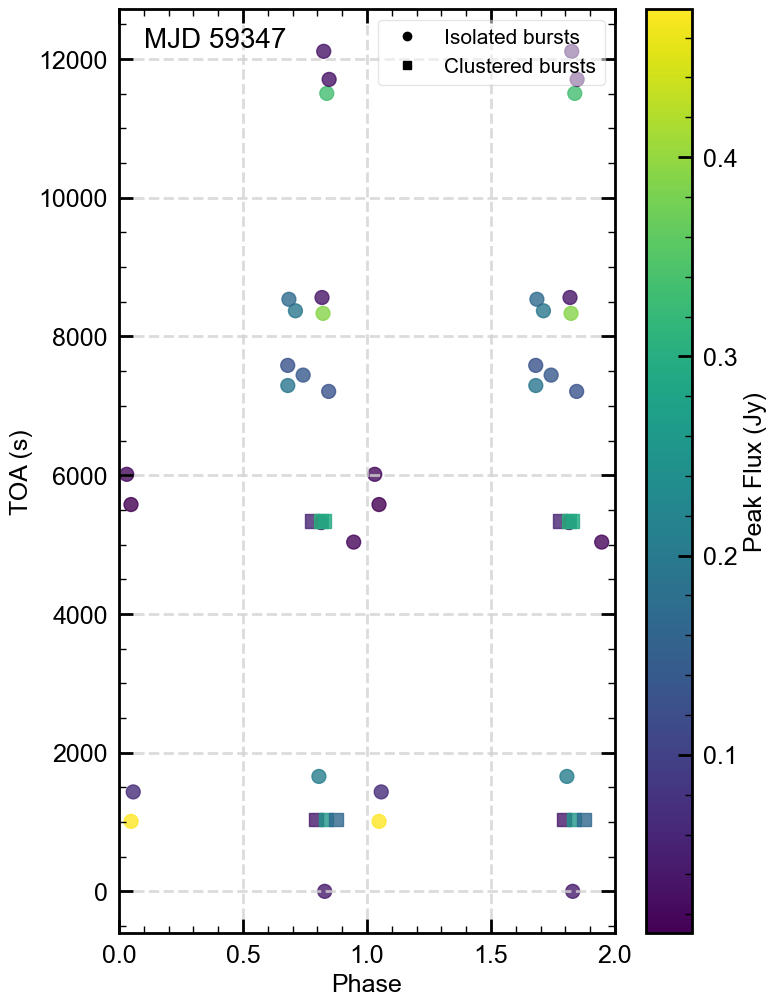

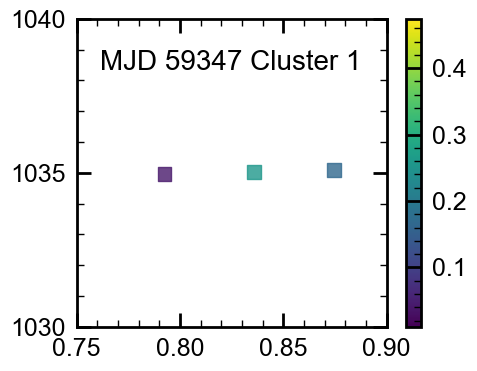

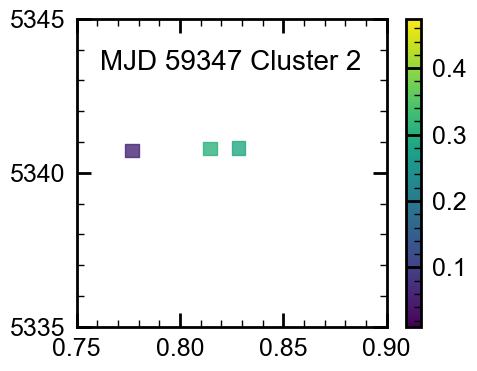

In [31]:
# Plot Supplementary Figure 6

def burstverify_anyday(bi,nummin,dnum,sep) :
    bi_ss=Xselectdata2(bi[1],nummin=nummin,dnum=dnum,sep=sep)
    b_s=[]
    for i in range(len(bi_ss[1])):
        b_s.append(bi_ss[1][i]['t']*86400)
        bi_ss[1][i]['t_s']=b_s[i]   
        bi_ss[1][i]['waitingtime0'] = np.concatenate(([np.inf], np.diff(b_s[i])))
        bi_ss[1][i]['waitingtime1'] = np.concatenate((np.diff(b_s[i]), [np.inf]))
    return bi_ss
b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)

def get_phase(t, period):
    phase = np.fmod(t/period, 1.0)
    phase = np.where(phase < 0.0, phase + 1.0, phase)
    return phase
    
# MJD 59310
day = 3
p=1.706024
b_sss = b_ss[1][day].loc[
                         (b_ss[1][day]['waitingtime0']>0.4)&(b_ss[1][day]['waitingtime1']>0.4)
                         ]
b_lll = b_ss[1][day].loc[
                         (b_ss[1][day]['waitingtime0']<0.4)|(b_ss[1][day]['waitingtime1']<0.4)
                         ]
folded_phases_sss = get_phase(b_sss['t_s']-np.mean(b_ss_fast1[1][day]['t_s']), p)
folded_phases_lll = get_phase(b_lll['t_s']-np.mean(b_ss_fast1[1][day]['t_s']), p)

cmap = plt.cm.viridis
z = b_ss_fast1[1][day]['s']
normz = plt.Normalize(vmin=min(z), vmax=max(z))
colors_s = cmap(normz(b_sss['s']))
colors_l = cmap(normz(b_lll['s']))

fig, ax = plt.subplots(1, 1, figsize=(8, 12))

ax.scatter(folded_phases_sss, b_sss['t_s']-b_sss['t_s'][0],
           marker='o', color=colors_s, s=100, alpha=0.8)
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
ax.scatter(folded_phases_sss+1, b_sss['t_s']-b_sss['t_s'][0],
           marker='o', color=colors_s, s=100, alpha=0.8)
ax.scatter(folded_phases_lll+1, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)


plt.ylabel('TOA (s)',labelpad=15) 
plt.xlabel('Phase')
plt.xlim(0, 2)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
cbar.set_label('Peak Flux (Jy)')  
legend_marker_x = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markersize=6, label='Isolated bursts') 
legend_marker_y = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                                markersize=6, label='Clustered bursts')

plt.text(0.05,0.98,'MJD 59310',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='left')

plt.legend(loc='upper right', handles=[legend_marker_x, legend_marker_y],
           fancybox=1, shadow=0, ncol=1,fontsize=15,framealpha=0.5)


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
plt.text(0.92,0.9,'MJD 59310 Cluster 1',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='right')
plt.xlim(0.1, 0.25)
ax.yaxis.get_major_formatter().set_useOffset(False)
ax.yaxis.set_major_locator(MultipleLocator(5))
plt.ylim(115, 125)
plt.ylabel(' ',fontsize=6)
plt.grid()


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
plt.text(0.92,0.9,'MJD 59310 Cluster 2',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='right')
plt.xlim(0.75, 0.9)
ax.yaxis.get_major_formatter().set_useOffset(False)
ax.yaxis.set_major_locator(MultipleLocator(5))
plt.ylim(1620, 1630)
plt.grid()


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
ax.scatter(folded_phases_lll+1, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
plt.text(0.92,0.9,'MJD 59310 Cluster 3',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='right')
plt.xlim(0.9, 1.05)
ax.yaxis.get_major_formatter().set_useOffset(False)
ax.yaxis.set_major_locator(MultipleLocator(5))
plt.ylim(5415, 5425)
plt.grid()


# MJD 59347
day = 35
t0=np.mean(b_ss_fast1[1][day]['t_s'])
p=1.707968
b_sss = b_ss[1][day].loc[
                         (b_ss[1][day]['waitingtime0']>0.4)&(b_ss[1][day]['waitingtime1']>0.4)
                         ]
b_lll = b_ss[1][day].loc[
                         (b_ss[1][day]['waitingtime0']<0.4)|(b_ss[1][day]['waitingtime1']<0.4)
                         ]
folded_phases_sss = get_phase(b_sss['t_s']-np.mean(b_ss_fast1[1][day]['t_s']), p)
folded_phases_lll = get_phase(b_lll['t_s']-np.mean(b_ss_fast1[1][day]['t_s']), p)

cmap = plt.cm.viridis
z = b_ss_fast1[1][day]['s']
normz = plt.Normalize(vmin=min(z), vmax=max(z))
colors_s = cmap(normz(b_sss['s']))
colors_l = cmap(normz(b_lll['s']))

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
ax.scatter(folded_phases_sss, b_sss['t_s']-b_sss['t_s'][0],
           marker='o', color=colors_s, s=100, alpha=0.8)
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
ax.scatter(folded_phases_sss+1, b_sss['t_s']-b_sss['t_s'][0],
           marker='o', color=colors_s, s=100, alpha=0.8)
ax.scatter(folded_phases_lll+1, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)

plt.ylabel('TOA (s)')  
plt.xlabel('Phase')
plt.xlim(0, 2)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
cbar.set_label('Peak Flux (Jy)')  
legend_marker_x = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                                markersize=6, label='Isolated bursts') 
legend_marker_y = mlines.Line2D([], [], color='black', marker='s', linestyle='None',
                                markersize=6, label='Clustered bursts')

plt.text(0.05,0.98,'MJD 59347',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='left')
plt.legend(loc='upper right', handles=[legend_marker_x, legend_marker_y],
           fancybox=1, shadow=0, ncol=1,fontsize=15,framealpha=0.5)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
plt.text(0.92,0.9,'MJD 59347 Cluster 1',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='right')
plt.xlim(0.75, 0.9)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.get_major_formatter().set_useOffset(False)
plt.ylim(1030, 1040)
plt.grid()

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(folded_phases_lll, b_lll['t_s']-b_sss['t_s'][0],
           marker='s', color=colors_l, s=100, alpha=0.8)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=normz, cmap=cmap), ax=ax)
plt.text(0.92,0.9,'MJD 59347 Cluster 2',transform=ax.transAxes, fontsize=20,
          verticalalignment='top', horizontalalignment='right')
plt.xlim(0.75, 0.9)
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.get_major_formatter().set_useOffset(False)
plt.ylim(5335, 5345)
plt.grid()

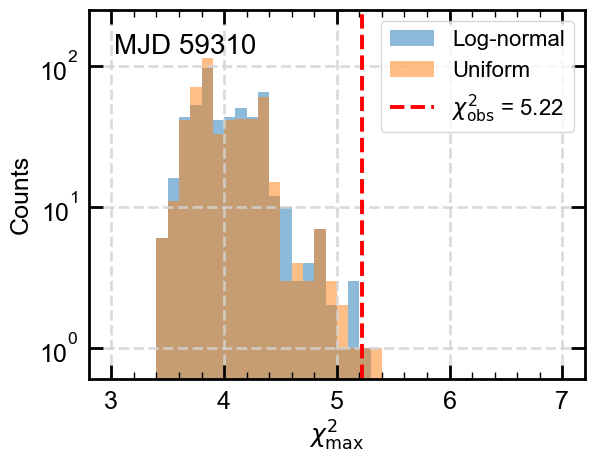

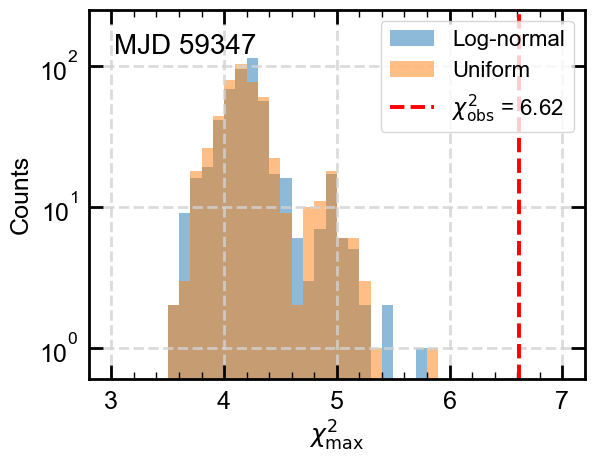

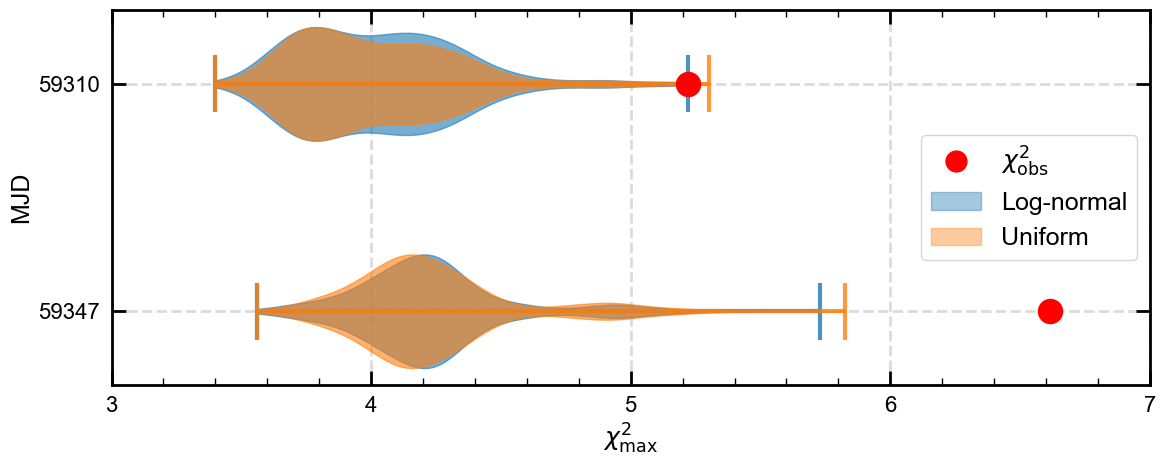

In [33]:
# Plot Supplementary Figure 7
# These simulated samples are consistent with those in the paper. 
# For details on how they were generated, please refer to 'Comparison_analysis.py'.
pf=r'Comparison_results\\'
filename_load_uniform=f'chi2_nulluniform_seed1_b30_num500_ps0.1_pe10_step1e-07_th0.4_brightest.npz'
mc_results_chi2_uniform = np.load(pf+filename_load_uniform)
chi2_days_uniform=mc_results_chi2_uniform['chi2_days_uniform']
chi2_period_days_uniform=mc_results_chi2_uniform['chi2_period_days_uniform']
chi2_days_obs=mc_results_chi2_uniform['chi2_days_obs']
chi2_period_days_obs=mc_results_chi2_uniform['chi2_period_days_obs']
meanT_days_uniform=mc_results_chi2_uniform['meanT_days']

filename_load_lognormal=f'chi2_nulllognormal_seed1_b30_num500_ps0.1_pe10_step1e-07_th0.4_brightest.npz'
mc_results_chi2_lognormal = np.load(pf+filename_load_lognormal)
chi2_days_lognormal=mc_results_chi2_lognormal['chi2_days_lognormal']
chi2_period_days_lognormal=mc_results_chi2_lognormal['chi2_period_days_lognormal']
chi2_days_obs1=mc_results_chi2_lognormal['chi2_days_obs']
chi2_period_days_obs1=mc_results_chi2_lognormal['chi2_period_days_obs']
meanT_days_lognormal=mc_results_chi2_lognormal['meanT_days']

# --- MJD 59310 ---
fig, ax=plt.subplots(1,1)
plt.hist(chi2_days_lognormal[0,:],bins=np.linspace(3,7,41),label='Log-normal',rwidth=1,alpha=0.5)
plt.hist(chi2_days_uniform[0,:],bins=np.linspace(3,7,41),label='Uniform',rwidth=1,alpha=0.5)
plt.axvline(chi2_days_obs[0],ls='--',color='r',label='$\\chi^2_{\\mathrm{obs}}$ = %.2f'%chi2_days_obs[0])
plt.yscale('log')
plt.ylim(0.6,0.25e3)
plt.text(0.05,0.88,'MJD 59310',transform=ax.transAxes,fontsize=20)
plt.ylabel('Counts')
plt.xlabel('$\\chi^2_{\\mathrm{max}}$')
plt.legend(loc='upper right',fontsize=16)
ax.yaxis.set_minor_locator(mticker.NullLocator())

# --- MJD 59347 ---
fig, ax=plt.subplots(1,1)
plt.hist(chi2_days_lognormal[1,:],bins=np.linspace(3,7,41),label='Log-normal',rwidth=1,alpha=0.5)
plt.hist(chi2_days_uniform[1,:],bins=np.linspace(3,7,41),label='Uniform',rwidth=1,alpha=0.5)
plt.axvline(chi2_days_obs[1],ls='--',color='r',label='$\\chi^2_{\\mathrm{obs}}$ = %.2f'%chi2_days_obs[1])
plt.yscale('log')
plt.ylim(0.6,0.25e3)
plt.text(0.05,0.88,'MJD 59347',transform=ax.transAxes,fontsize=20)
plt.ylabel('Counts')
plt.xlabel('$\\chi^2_{\\mathrm{max}}$')
plt.legend(loc='upper right',fontsize=16)
ax.yaxis.set_minor_locator(mticker.NullLocator())


dates_mjd=[]
fn_chi2days_lognormal=[chi2_days_lognormal[0,:],chi2_days_lognormal[1,:]]
fn_chi2days_possion=[chi2_days_uniform[0,:],chi2_days_uniform[1,:]]
chi2days_obs=chi2_days_obs

fig, ax = plt.subplots(figsize=(12,5)) 

violin_width = 0.5 
        

def customize_violin(vp, color):

    for pc in vp['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.6)
        pc.set_zorder(2)

    for partname in ('cbars', 'cmins', 'cmaxes'):
        if partname in vp:
            vp[partname].set_edgecolor(color) 
            vp[partname].set_linewidth(3)
            vp[partname].set_alpha(0.8)
            
# --- MJD 59310 ---
vp1_1 = ax.violinplot(fn_chi2days_lognormal[0], positions=[1], vert=False, 
                    showmeans=0, showmedians=0, showextrema=True, widths=violin_width)
customize_violin(vp1_1, 'tab:blue')
vp2_1 = ax.violinplot(fn_chi2days_possion[0], positions=[1], vert=False, 
                    showmeans=0, showmedians=0, showextrema=True, widths=violin_width)
customize_violin(vp2_1, 'tab:orange')
# --- MJD 59347  ---
vp1_2 = ax.violinplot(fn_chi2days_lognormal[1], positions=[2], vert=False, 
                    showmeans=False, showmedians=False, showextrema=True, widths=violin_width)
customize_violin(vp1_2, 'tab:blue')
vp2_2 = ax.violinplot(fn_chi2days_possion[1], positions=[2], vert=False, 
                    showmeans=False, showmedians=False, showextrema=True, widths=violin_width)
customize_violin(vp2_2, 'tab:orange')

ax.scatter(chi2days_obs[0],1,color='r', 
            s=300, zorder=3)
ax.scatter(chi2days_obs[1],2,color='r', 
            s=300, zorder=3)

ax.set_yticks([1,2],[59310,59347]) 
plt.gca().invert_yaxis()
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set_ylabel("MJD") 
ax.set_xlabel("$\\chi^2_{\\mathrm{max}}$") 
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.set_xlim(3,7)

obs_handle = Line2D([0], [0], marker='o', color='r', label='$\\chi^2_{\\mathrm{obs}}$', 
                       linestyle='None', markersize=15)
lognormal_handle = mpatches.Patch(color='tab:blue', alpha=0.4, label='Log-normal')
possion_handle = mpatches.Patch(color='tab:orange', alpha=0.4, label='Uniform')

ax.legend(loc='center right',handles=[obs_handle,lognormal_handle, possion_handle])
plt.tight_layout() 

 50%|██████████████████████████████████████████                                          | 1/2 [00:05<00:05,  5.69s/it]


MJD 59310
Period: 3.41207 s
H_20: 70.82


100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:09<00:00,  4.85s/it]


MJD 59347
Period: 1.70797 s
H_20: 80.29


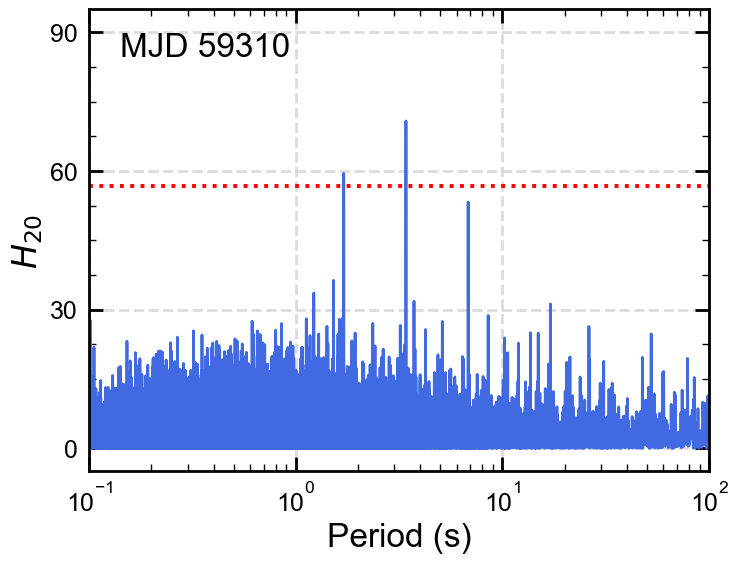

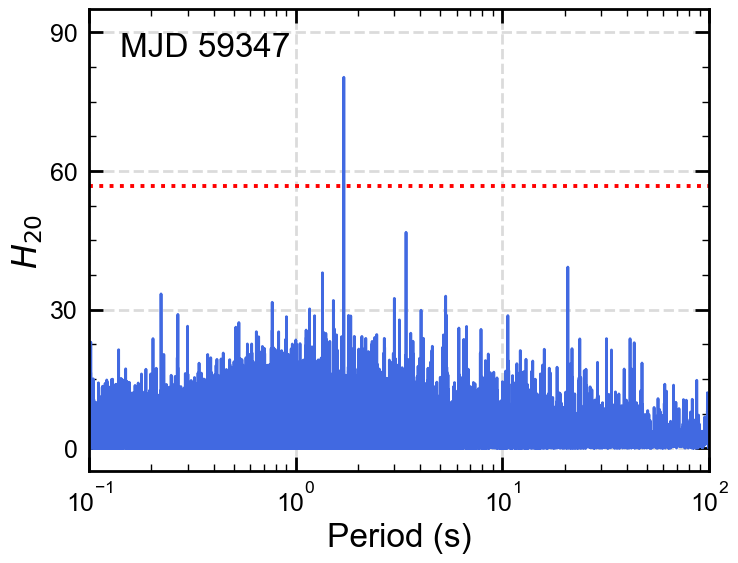

In [23]:
# Plot Supplementary Figure 8
@njit(parallel=True, fastmath=True)
def phase_fold_and_calc_H_opt(t, p_arr, harmonics):
    """
    H-test calculation
    """
    N = len(t)
    num_periods = len(p_arr)
    H_array = np.zeros(num_periods, dtype=np.float64)
    two_pi = 2.0 * np.pi
    for i in prange(num_periods):
        p = p_arr[i]
        inv_p = 1.0 / p
        sum_c = np.zeros(harmonics, dtype=np.float64)
        sum_s = np.zeros(harmonics, dtype=np.float64)
        for n in range(N):
            phase = (t[n] * inv_p) % 1.0
            theta = two_pi * phase
            c1 = np.cos(theta)
            s1 = np.sin(theta)
            sum_c[0] += c1
            sum_s[0] += s1
            cmx = c1
            smx = s1
            for h in range(1, harmonics):
                c_new = cmx * c1 - smx * s1
                s_new = smx * c1 + cmx * s1
                sum_c[h] += c_new
                sum_s[h] += s_new
                cmx = c_new
                smx = s_new
        cumulative_Z2 = 0.0
        max_H = -np.inf 
        for h in range(harmonics):
            # Z_m^2 = 2/N * (C^2 + S^2)
            Zm2 = 2.0 * (sum_c[h]**2 + sum_s[h]**2) / N
            cumulative_Z2 += Zm2
            current_H = cumulative_Z2 - 4.0 * (h + 1) + 4.0
            if current_H > max_H:
                max_H = current_H
        H_array[i] = max_H
    return H_array

def segmented_search_H(b_ss, day, ps, pe, step, harmonics, threshold):
    def _get_rep_times(df_day, threshold):
        b_rep = get_cluster_representatives(df_day, threshold)
        return np.asarray(b_rep["t_s"], dtype=np.float64)
    if step <= 0:
        raise ValueError("Step size must be positive.")
    if pe < ps:
        raise ValueError("End period must be greater than start period.")
    df_day = b_ss[1][day]
    num_points = int(np.round((pe - ps) / step)) + 1
    p_arr = np.linspace(ps, pe, num_points, dtype=np.float64)
    
    split = float(threshold) * 2.0
    t_all = np.asarray(df_day["t_s"], dtype=np.float64)
    mask_long = p_arr >= split
    has_long = np.any(mask_long)
    has_short = np.any(~mask_long)
    if not has_long:
        H_arr = phase_fold_and_calc_H_opt(t_all, p_arr, harmonics)
    
    elif not has_short:
        t_rep = _get_rep_times(df_day, threshold)
        H_arr = phase_fold_and_calc_H_opt(t_rep, p_arr, harmonics)
    
    else:
        p_short = p_arr[~mask_long]
        p_long  = p_arr[mask_long]
        
        H_short = phase_fold_and_calc_H_opt(t_all, p_short, harmonics)
        
        t_rep = _get_rep_times(df_day, threshold)
        H_long = phase_fold_and_calc_H_opt(t_rep, p_long, harmonics)
        
        H_arr = np.concatenate([H_short, H_long])
        
        del H_short, H_long
        gc.collect()
    best_idx = np.argmax(H_arr)
    best_p = p_arr[best_idx]
    result = {
        "H_array": H_arr.astype(np.float32),
        "best_p": best_p,  
        "max_H": H_arr[best_idx],
        "MJD": np.floor(np.min(df_day["t"])) if len(df_day) > 0 else 0,
        "N_burst": int(len(df_day)),
    }
    return result


b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)
gc.collect()

for i in tqdm.tqdm([3,35]):
    gc.collect()
    ps=0.1
    pe=100
    step=1e-5
    threshold = 0.4
    harmonics = 20
    sig=np.log((1 - stats.norm.cdf(3))/((100-0.1)*1e5))/-0.4
    r=segmented_search_H(b_ss, i, ps, pe, step, harmonics, threshold)
    fig, ax=plt.subplots(figsize=(8,6))
    ax.plot(np.linspace(ps,pe,int(np.round((pe-ps)/step))+1), r['H_array'], alpha=1, lw=2, color='royalblue')
    ax.set_xscale('log')
    ax.axhline(sig, color='red', linestyle='dotted')
    ax.text(0.05, 0.95, 'MJD %i' % r['MJD'], transform=ax.transAxes, fontsize=24,
              verticalalignment='top', horizontalalignment='left')
    ax.set_xlim(ps, pe)
    ax.yaxis.set_major_locator(MultipleLocator(30))
    ax.set_ylim(-5,95)
    ax.set_xlabel('Period (s)',fontsize=24)
    ax.set_ylabel('$H_{\\mathrm{20}}$',fontsize=24)
    print(f"\nMJD {int(r['MJD'])}")
    print(f"Period: {r['best_p']:.5f} s")
    print(f"H_20: {r['max_H']:.2f}")
    del r, fig, ax
    gc.collect()


Scanning bins_num: 100%|███████████████████████████████████████████████████████████████| 31/31 [00:04<00:00,  6.61it/s]


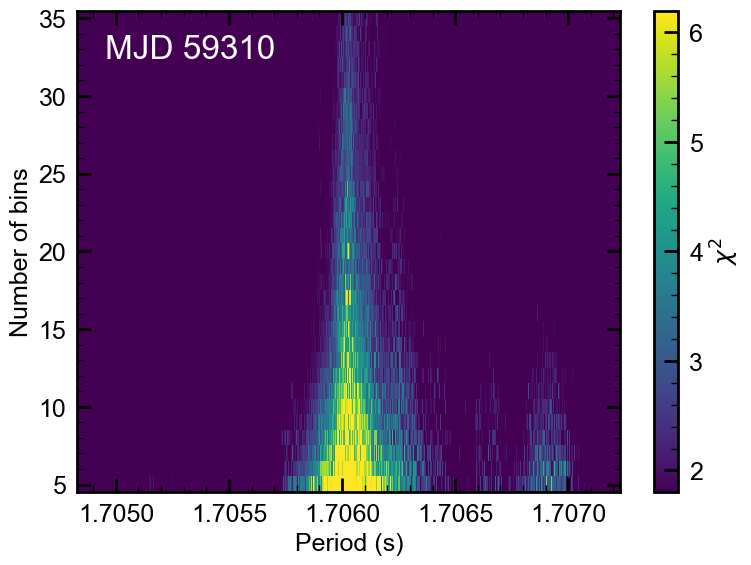

Scanning bins_num: 100%|███████████████████████████████████████████████████████████████| 31/31 [00:03<00:00,  8.23it/s]


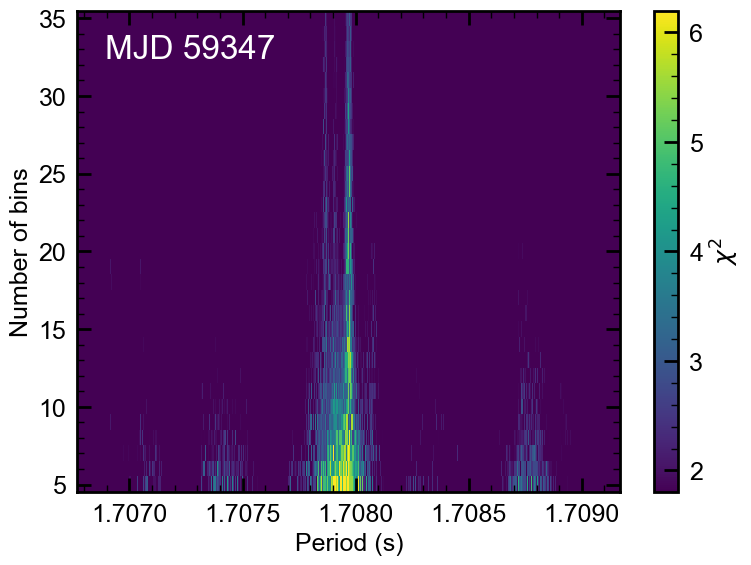

In [25]:
# Plot Supplementary Figure 9

b_ss=burstverify_anyday(b_fast1, nummin=1,dnum=1,sep=0)

day = 3                   # MJD 59310
pc = 1.70603
wi = 0.0012
ps = pc-wi                 
pe = pc+wi
step = 1e-7
threshold = 0.5

bins_list = np.arange(5, 36, 1)   


p_arr = np.linspace(ps, pe, int(np.round((pe - ps) / step)) + 1)


chi2_map = np.empty((len(bins_list), len(p_arr)), dtype=np.float32)

best_periods = []
best_chi2s = []

for ib, bins_num in enumerate(tqdm.tqdm(bins_list, desc='Scanning bins_num')):
    r = segmented_search_chi2(
        b_ss, day,
        ps=ps, pe=pe, step=step,
        bins_num=int(bins_num),
        threshold=threshold,
    )
    
    chi2_map[ib, :] = r['chi2_array']
    best_periods.append(r['best_p'])
    best_chi2s.append(r['max_chi2'])
    
    del r
    gc.collect()

best_periods = np.array(best_periods)
best_chi2s = np.array(best_chi2s)


fig, ax = plt.subplots(figsize=(8,6))

dp = np.median(np.diff(p_arr))
x_min = p_arr.min() - 0.5 * dp
x_max = p_arr.max() + 0.5 * dp
y_min = bins_list.min() - 0.5
y_max = bins_list.max() + 0.5
mesh = ax.imshow(
    chi2_map,
    origin='lower',
    aspect='auto',
    interpolation='none',
    cmap='viridis',
    vmin=1.8,
    vmax=6.2,
    extent=[x_min, x_max, y_min, y_max],
)

cbar = plt.colorbar(mesh, ax=ax,ticks=[2, 3, 4, 5, 6])
cbar.set_label(r'$\chi^2$')

# ax.plot(best_periods, bins_list, color='r', lw=1.5, label='Best period')

ax.set_xlabel('Period (s)')
ax.set_ylabel('Number of bins')
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.text(0.05, 0.95, 'MJD 59310', transform=ax.transAxes, fontsize=24,color='white',
          verticalalignment='top', horizontalalignment='left')
# ax.tick_params(axis='both', which='both', color='white', labelcolor='black')
plt.grid()
plt.tight_layout()
plt.show()

day = 35                   # MJD 59347
pc = 1.70797
wi = 0.0012
ps = pc-wi                 
pe = pc+wi
step = 1e-7
threshold = 0.5

bins_list = np.arange(5, 36, 1)   


p_arr = np.linspace(ps, pe, int(np.round((pe - ps) / step)) + 1)


chi2_map = np.empty((len(bins_list), len(p_arr)), dtype=np.float32)

best_periods = []
best_chi2s = []

for ib, bins_num in enumerate(tqdm.tqdm(bins_list, desc='Scanning bins_num')):
    r = segmented_search_chi2(
        b_ss, day,
        ps=ps, pe=pe, step=step,
        bins_num=int(bins_num),
        threshold=threshold,
    )
    
    chi2_map[ib, :] = r['chi2_array']
    best_periods.append(r['best_p'])
    best_chi2s.append(r['max_chi2'])
    
    del r
    gc.collect()

best_periods = np.array(best_periods)
best_chi2s = np.array(best_chi2s)


fig, ax = plt.subplots(figsize=(8,6))

dp = np.median(np.diff(p_arr))
x_min = p_arr.min() - 0.5 * dp
x_max = p_arr.max() + 0.5 * dp
y_min = bins_list.min() - 0.5
y_max = bins_list.max() + 0.5
mesh = ax.imshow(
    chi2_map,
    origin='lower',
    aspect='auto',
    interpolation='none',
    cmap='viridis',
    vmin=1.8,
    vmax=6.2,
    extent=[x_min, x_max, y_min, y_max],
)

cbar = plt.colorbar(mesh, ax=ax,ticks=[2, 3, 4, 5, 6])
cbar.set_label(r'$\chi^2$')

# ax.plot(best_periods, bins_list, color='r', lw=1.5, label='Best period')

ax.set_xlabel('Period (s)')
ax.set_ylabel('Number of bins')
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.text(0.05, 0.95, 'MJD 59347', transform=ax.transAxes, fontsize=24,color='white',
          verticalalignment='top', horizontalalignment='left')
# ax.tick_params(axis='both', which='both', color='white', labelcolor='black')
plt.grid()
plt.tight_layout()
plt.show()